# 05 - From PNG with Metadata Presets

Ejemplos de carga de una imagen PNG en `MammographyDicom`, inicializacion con presets/defaults de metadata y actualizacion de metadata tras el procesado.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'api_stable').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from api_stable.mammography import MammographyDicom

In [2]:
PNG_PATH = Path('/home/eloygarcia/Escritorio/Datasets/RSNA_png/train_images/5/640805896.png')
if not PNG_PATH.exists():
    raise FileNotFoundError(f'Actualiza PNG_PATH: {PNG_PATH}')

print('PNG_PATH =', PNG_PATH)

PNG_PATH = /home/eloygarcia/Escritorio/Datasets/RSNA_png/train_images/5/640805896.png


39.0 240.0
159.03 53.98
39.0 240.0
159.03 53.98
39.0 240.0
159.03 53.98
MammographyMetadata(patient=PatientInfo(patient_id=None, age=None, sex=None), vendor=VendorInfo(manufacturer='HOLOGIC, Inc.', model_name='Selenia Dimensions'), acquisition=AcquisitionInfo(kvp=None, exposure=None, exposure_time=None, tube_current=None, compression_force=None), breast=BreastInfo(laterality=None, view=None, breast_implant_present=None), image=ImageInfo(rows=2776, columns=2082, bits_stored=8, pixel_spacing=(0.07, 0.07), photometric_interpretation='MONOCHROME2', presentation_lut_shape='IDENTITY', window_center=159, window_width=53, window_center_width_explanation='AUTO', voi_lut_function='LINEAR'))


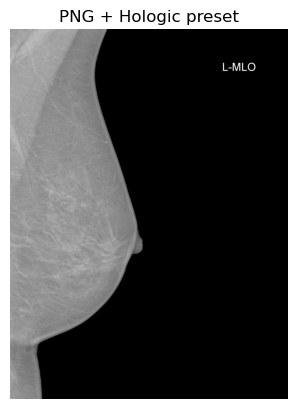

In [3]:
mammo_hologic = MammographyDicom.from_png(
    PNG_PATH,
    metadata_preset='Hologic',
)

print(mammo_hologic.metadata)

original = mammo_hologic.image.to_numpy()

plt.imshow(original, cmap='gray')
plt.title('PNG + Hologic preset')
plt.axis('off')
plt.show()

39.15354 240.94489
159.6561 54.192524
39.15354 240.94489
159.6561 54.192524
ImageInfo(rows=2776, columns=2082, bits_stored=None, pixel_spacing=(0.07, 0.07), photometric_interpretation='MONOCHROME2', presentation_lut_shape='IDENTITY', window_center=np.float64(127.5), window_width=np.uint8(255), window_center_width_explanation='APPLIED', voi_lut_function='LINEAR')
['apply_windowing( window_center=127.5, window_width=255, voi_lut_function=LINEAR)']


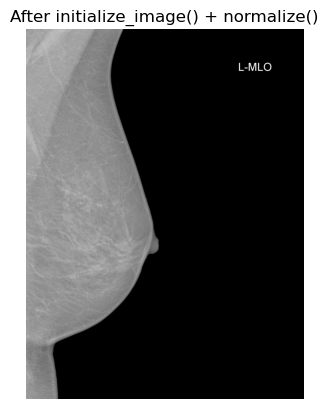

In [4]:
mammo_hologic.initialize_image()
# mammo_hologic.normalize()

print(mammo_hologic.metadata.image)
print(mammo_hologic.image.get_history())


plt.imshow(mammo_hologic.image.to_numpy(), cmap='gray')
plt.title('After initialize_image() + normalize()')
plt.axis('off')
plt.show()

In [5]:
mammo_custom = MammographyDicom.from_png(
    PNG_PATH,
    metadata_defaults={
        'vendor': {
            'manufacturer': 'CUSTOM_VENDOR',
            'model_name': 'CUSTOM_MODEL',
        },
        'image': {
            'photometric_interpretation': 'MONOCHROME1',
        },
    },
)

print(mammo_custom.metadata)

39.0 240.0
159.03 53.98
39.0 240.0
159.03 53.98
39.0 240.0
159.03 53.98
MammographyMetadata(patient=PatientInfo(patient_id=None, age=None, sex=None), vendor=VendorInfo(manufacturer='CUSTOM_VENDOR', model_name='CUSTOM_MODEL'), acquisition=AcquisitionInfo(kvp=None, exposure=None, exposure_time=None, tube_current=None, compression_force=None), breast=BreastInfo(laterality=None, view=None, breast_implant_present=None), image=ImageInfo(rows=2776, columns=2082, bits_stored=8, pixel_spacing=None, photometric_interpretation='MONOCHROME1', presentation_lut_shape='IDENTITY', window_center=159, window_width=53, window_center_width_explanation='AUTO', voi_lut_function='LINEAR'))


In [6]:
import os

mammo_override = MammographyDicom.from_png(
    PNG_PATH,
    metadata_preset='GE',
    metadata_overrides={
        'patient':{'patient_id': os.path.basename(PNG_PATH)},
        'breast': {'laterality': 'L', 'view': 'MLO'},
        #'image': {'photometric_interpretation': 'MONOCHROME1'},
    },
)

mammo_override.initialize_image()
print(mammo_override.metadata)

39.0 240.0
159.03 53.98
39.0 240.0
159.03 53.98
39.0 240.0
159.03 53.98
12.761147 241.29059
144.80948 64.32074
12.761147 241.29059
144.80948 64.32074
MammographyMetadata(patient=PatientInfo(patient_id='640805896.png', age=None, sex=None), vendor=VendorInfo(manufacturer='GE Healthcare', model_name='Senographe Pristina'), acquisition=AcquisitionInfo(kvp=None, exposure=None, exposure_time=None, tube_current=None, compression_force=None), breast=BreastInfo(laterality='L', view='MLO', breast_implant_present=None), image=ImageInfo(rows=2776, columns=2082, bits_stored=None, pixel_spacing=(0.1, 0.1), photometric_interpretation='MONOCHROME2', presentation_lut_shape='IDENTITY', window_center=159, window_width=53, window_center_width_explanation='APPLIED', voi_lut_function='SIGMOID'))


['apply_windowing( window_center=159, window_width=53, voi_lut_function=SIGMOID)']


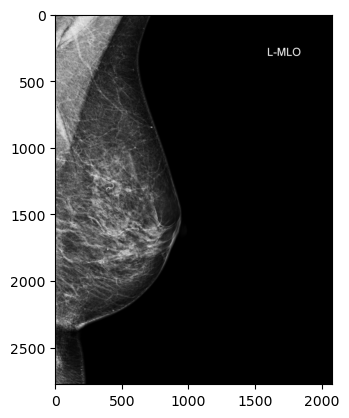

In [7]:
print(mammo_override.image.get_history())

plt.imshow(mammo_override.image.to_numpy(), cmap='gray')
plt.show()

In [8]:

print(3*original.astype('float32').max()/4)


191.25


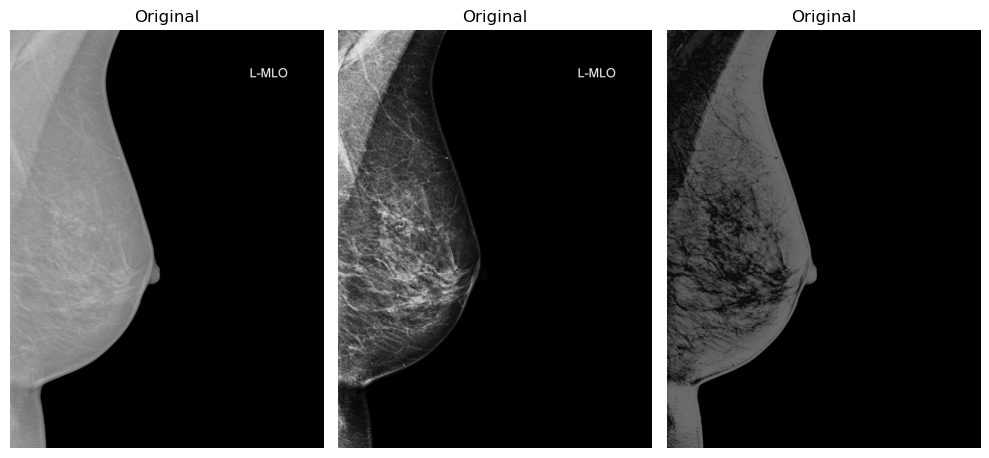

In [9]:
import numpy as np

fig, ax = plt.subplots(1, 3, figsize=(10, 5))

ax[0].imshow(original, vmin=original.min(), vmax=original.max(), cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')
plt.tight_layout()

ax[1].imshow(mammo_override.image.to_numpy(), vmin=original.min(), vmax=original.max(), cmap='gray')
ax[1].set_title('Original')
ax[1].axis('off')
plt.tight_layout()

ax[2].imshow(np.abs(mammo_override.image.to_numpy() - original), vmin=original.min(), vmax=original.max(), cmap='gray')
ax[2].set_title('Original')
ax[2].axis('off')
plt.tight_layout()


In [10]:
# Exportar la instancia a DICOM y validar roundtrip
import pydicom

output_dcm = PROJECT_ROOT / 'api_stable' / 'tests' / 'artifacts' / 'png_export_example.dcm'
output_dcm.parent.mkdir(parents=True, exist_ok=True)

saved_path = mammo_override.save_as_dicom(output_dcm)
print('DICOM guardado en:', saved_path)

# Leer el DICOM generado para comprobar metadatos y pixel data
ds_roundtrip = pydicom.dcmread(saved_path)
print('Rows x Cols:', ds_roundtrip.Rows, 'x', ds_roundtrip.Columns)
print('PhotometricInterpretation:', ds_roundtrip.PhotometricInterpretation)
print('Manufacturer:', getattr(ds_roundtrip, 'Manufacturer', None))
print('Model:', getattr(ds_roundtrip, 'ManufacturerModelName', None))
print('PatientID:', getattr(ds_roundtrip, 'PatientID', None))
print('Laterality/View:', getattr(ds_roundtrip, 'ImageLaterality', None), getattr(ds_roundtrip, 'ViewPosition', None))
print('WindowCenter/Width:', getattr(ds_roundtrip, 'WindowCenter', None), getattr(ds_roundtrip, 'WindowWidth', None))
print('SOPInstanceUID:', ds_roundtrip.SOPInstanceUID)

# Verificación mínima
assert ds_roundtrip.Rows == mammo_override.image.shape[0]
assert ds_roundtrip.Columns == mammo_override.image.shape[1]
assert ds_roundtrip.Manufacturer == mammo_override.metadata.vendor.manufacturer
print('Roundtrip DICOM OK')

DICOM guardado en: /home/eloygarcia/Escritorio/WorkInProgress/Preprocessing/api_stable/tests/artifacts/png_export_example.dcm
Rows x Cols: 2776 x 2082
PhotometricInterpretation: MONOCHROME2
Manufacturer: GE Healthcare
Model: Senographe Pristina
PatientID: 640805896.png
Laterality/View: L MLO
WindowCenter/Width: 159.0 53.0
SOPInstanceUID: 1.2.826.0.1.3680043.8.498.71057697100594927347916153162686415782
Roundtrip DICOM OK
